<hr>

**<h1> CS437/CS5317/EE414/EE513 Deep Learning |  PA4</h1>**

<hr>

# **Submission Guidelines**

- Please rename the file to `<RollNumber>_PA4_2`.
- Please also submit a **.py** file of every Notebook. You can do this by exporting your **ipynb** to a Python script.
- Please submit a zipped folder of both your Jupyter Notebooks and Python script files.

In [1]:
Name = "Hannan Mustafa"
Roll_Number = 27100330

## Setup — Imports & Device

In [2]:
import math
import time
import collections
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


---
## Part A — Modifying the Attention Mechanism

CIFAR-10 image classification using a small ViT.  
**Dataset:** 20,000-sample training subset, full 10,000 validation set.  
**Training config:** 15 epochs, Adam lr=3e-4, CosineAnnealingLR, CrossEntropyLoss, grad clip=1.0.


### Baseline: Scaled Dot-Product Attention
Reference implementation. **Do not modify.**

In [5]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Args
        Q, K : (B, H, N, d_k)
        V    : (B, H, N, d_v)
        mask : optional boolean mask (True = ignore)
    Returns
        out  : (B, H, N, d_v)
        attn : (B, H, N, N)
    """
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))
    attn = F.softmax(scores, dim=-1)
    return torch.matmul(attn, V), attn


### Shared Transformer Building Blocks
`MultiHeadAttention` and `TransformerBlock` — provided. Do not modify.

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, attention_fn=None):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)
        self.attention_fn = attention_fn or scaled_dot_product_attention

    def forward(self, x):
        B, N, D = x.shape
        def split(t):
            return t.view(B, N, self.n_heads, self.d_k).transpose(1, 2)
        Q = split(self.Wq(x))
        K = split(self.Wk(x))
        V = split(self.Wv(x))
        out, attn_w = self.attention_fn(Q, K, V)
        out = out.transpose(1, 2).contiguous().view(B, N, D)
        return self.Wo(out), attn_w


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim, attention_fn=None):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads, attention_fn)
        self.ff   = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, _ = self.attn(self.ln1(x))
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x


### Dataset — CIFAR-10 (Part A)

In [7]:
import torchvision
import torchvision.transforms as T

IMG_SIZE   = 32
PATCH_SIZE = 4          # (32/4)^2 = 64 tokens per image
BATCH_A    = 128

transform_a = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616)),
])
transform_val = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616)),
])

cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=transform_a)
cifar_val   = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform_val)

# 20k subset for Part A experiments
cifar_train_sub = torch.utils.data.Subset(cifar_train, range(20_000))

loader_train_a = torch.utils.data.DataLoader(cifar_train_sub, batch_size=BATCH_A,
                                              shuffle=True,  num_workers=2, pin_memory=True)
loader_val_a   = torch.utils.data.DataLoader(cifar_val,      batch_size=256,
                                              shuffle=False, num_workers=2, pin_memory=True)
CLASSES = cifar_train.classes
print(f"Train subset: {len(cifar_train_sub)}  |  Val: {len(cifar_val)}")


100%|██████████| 170M/170M [00:06<00:00, 26.8MB/s] 


Train subset: 20000  |  Val: 10000


### Model — ViT Classifier for Part A
Provided. Uses `LinearPatchEmbeddingA` and accepts an `attention_fn` argument.

In [8]:
class LinearPatchEmbeddingA(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, d_model):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches  = (img_size // patch_size) ** 2
        self.proj = nn.Linear(patch_size * patch_size * in_channels, d_model)

    def forward(self, x):
        B, C, H, W = x.shape; P = self.patch_size
        x = x.unfold(2, P, P).unfold(3, P, P)
        x = x.contiguous().view(B, C, -1, P, P)
        x = x.permute(0, 2, 1, 3, 4).contiguous().view(B, self.n_patches, -1)
        return self.proj(x)


class ViTClassifierA(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 d_model=64, n_layers=2, n_heads=4, num_classes=10,
                 attention_fn=None):
        super().__init__()
        self.embedding = LinearPatchEmbeddingA(img_size, patch_size, in_channels, d_model)
        n_patches = self.embedding.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_emb   = nn.Parameter(torch.randn(1, n_patches + 1, d_model) * 0.02)
        self.blocks    = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_model * 2, attention_fn)
            for _ in range(n_layers)])
        self.ln   = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.size(0)
        tokens = self.embedding(x)
        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1) + self.pos_emb
        for blk in self.blocks:
            tokens = blk(tokens)
        return self.head(self.ln(tokens[:, 0]))


### Training & Evaluation Helpers (Part A)
Provided. Do not modify.

In [9]:
def train_epoch_a(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0., 0, 0
    grad_norms = []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        gnorm = sum(p.grad.detach().norm().item()**2
                    for p in model.parameters() if p.grad is not None) ** 0.5
        grad_norms.append(gnorm)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
    return total_loss / n, correct / n, sum(grad_norms) / len(grad_norms)


@torch.no_grad()
def evaluate_a(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0., 0, 0
    class_correct = torch.zeros(10)
    class_total   = torch.zeros(10)
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * imgs.size(0)
        preds   = logits.argmax(1)
        correct += (preds == labels).sum().item()
        n       += imgs.size(0)
        for c in range(10):
            mask = labels == c
            class_correct[c] += (preds[mask] == c).sum().item()
            class_total[c]   += mask.sum().item()
    per_class_acc = (class_correct / class_total.clamp(min=1)).numpy()
    return total_loss / n, correct / n, per_class_acc


def attn_entropy(attn_w):
    """Mean Shannon entropy of attention distributions. attn_w: (B,H,N,N)"""
    eps = 1e-9
    return -(attn_w * (attn_w + eps).log()).sum(-1).mean().item()


@torch.no_grad()
def measure_entropy(model, loader, attn_fn, n_batches=5):
    """Average CLS-token attention entropy over n_batches mini-batches."""""
    model.eval()
    entropies = []
    for i, (imgs, _) in enumerate(loader):
        if i >= n_batches: break
        imgs = imgs.to(DEVICE)
        B    = imgs.size(0)
        tokens = model.embedding(imgs)
        cls    = model.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1) + model.pos_emb
        x_ln = model.blocks[0].ln1(tokens)
        d_k  = model.blocks[0].attn.d_k
        n_h  = model.blocks[0].attn.n_heads
        N    = x_ln.size(1)
        def split(t): return t.view(B, N, n_h, d_k).transpose(1, 2)
        Q = split(model.blocks[0].attn.Wq(x_ln))
        K = split(model.blocks[0].attn.Wk(x_ln))
        V = split(model.blocks[0].attn.Wv(x_ln))
        _, aw = attn_fn(Q, K, V)
        entropies.append(attn_entropy(aw))
    return sum(entropies) / len(entropies)


---
### Task 1 — Top-k Sparse Attention

**[1.1] Your implementation below.**

For each query, compute standard scaled scores, retain only the **k** highest-scoring keys (mask the rest to `-inf`), then apply softmax.  
Signature must match `scaled_dot_product_attention` plus the integer argument `k`.  
Shape: inputs are `(B, H, N, d_k)`.


In [15]:
def topk_attention(Q, K, V, k):
    """
    Args
        Q, K : (B, H, N, d_k)
        V    : (B, H, N, d_v)
        k    : number of keys each query attends to
    Returns
        out  : (B, H, N, d_v)
        attn : (B, H, N, N)
    """
    # TODO: implement top-k sparse attention
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    topk_vals, _ = torch.topk(scores, k, dim=-1)
    tau = topk_vals[..., -1:]
    scores = scores.masked_fill(scores < tau, float('-inf'))
    attn = F.softmax(scores, dim=-1)
    out = torch.matmul(attn, V)
    
    return out, attn


**[1.2] Sanity check**

In [16]:
B, H, N, d_k = 2, 4, 16, 32
Q_ = torch.randn(B, H, N, d_k)
K_ = torch.randn(B, H, N, d_k)
V_ = torch.randn(B, H, N, d_k)

out_full, _ = scaled_dot_product_attention(Q_, K_, V_)
out_topk, _ = topk_attention(Q_, K_, V_, k=N)
assert torch.allclose(out_full, out_topk, atol=1e-5), "Outputs differ when k == N"
print('Sanity check passed.')


Sanity check passed.


**[1.3] Experiment A1 — Top-k sweep.**

Run for k ∈ {4, 16, 32, full}. Training config is set below. Do not change the hyperparameters.


In [17]:
# Training configuration — do not change
EPOCHS_A   = 15
LR_A       = 3e-4
CRIT_A     = nn.CrossEntropyLoss()
K_VALS     = [4, 16, 32, None]   # None = full attention (N=65)
N_PATCHES  = (IMG_SIZE // PATCH_SIZE) ** 2   # 64
N_FULL     = N_PATCHES + 1                   # +1 for CLS

def run_topk_experiment(k_values=K_VALS, epochs=EPOCHS_A):
    results = {}
    for k in k_values:
        torch.manual_seed(42)
        label   = 'full' if k is None else str(k)
        attn_fn = (scaled_dot_product_attention if k is None
                   else lambda Q, K, V, _k=k: topk_attention(Q, K, V, k=_k))
        model  = ViTClassifierA(attention_fn=attn_fn).to(DEVICE)
        opt    = torch.optim.Adam(model.parameters(), lr=LR_A)
        sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        r = collections.defaultdict(list)
        for ep in range(1, epochs + 1):
            t0 = time.perf_counter()
            tr_loss, tr_acc, gnorm = train_epoch_a(model, loader_train_a, opt, CRIT_A)
            val_loss, val_acc, per_cls = evaluate_a(model, loader_val_a, CRIT_A)
            ent = measure_entropy(model, loader_val_a, attn_fn)
            sched.step()
            elapsed = time.perf_counter() - t0
            r['tr_loss'].append(tr_loss);  r['val_loss'].append(val_loss)
            r['tr_acc'].append(tr_acc);    r['val_acc'].append(val_acc)
            r['gnorm'].append(gnorm);      r['entropy'].append(ent)
            r['epoch_time'].append(elapsed)
            r['per_cls'].append(per_cls)
            print(f"  k={label:>4s} ep {ep:02d}/{epochs} "
                  f"tr_loss={tr_loss:.4f} val_acc={val_acc:.3f} "
                  f"entropy={ent:.3f} gnorm={gnorm:.3f}")
        results[label] = dict(r)
    return results

topk_res = run_topk_experiment()


  k=   4 ep 01/15 tr_loss=1.9846 val_acc=0.323 entropy=1.380 gnorm=1.932
  k=   4 ep 02/15 tr_loss=1.8117 val_acc=0.366 entropy=1.378 gnorm=2.506
  k=   4 ep 03/15 tr_loss=1.7103 val_acc=0.401 entropy=1.378 gnorm=3.172
  k=   4 ep 04/15 tr_loss=1.6554 val_acc=0.411 entropy=1.377 gnorm=3.714
  k=   4 ep 05/15 tr_loss=1.5990 val_acc=0.434 entropy=1.376 gnorm=3.863
  k=   4 ep 06/15 tr_loss=1.5622 val_acc=0.442 entropy=1.376 gnorm=4.436
  k=   4 ep 07/15 tr_loss=1.5198 val_acc=0.460 entropy=1.375 gnorm=4.328
  k=   4 ep 08/15 tr_loss=1.4935 val_acc=0.471 entropy=1.375 gnorm=4.483
  k=   4 ep 09/15 tr_loss=1.4753 val_acc=0.468 entropy=1.377 gnorm=4.769
  k=   4 ep 10/15 tr_loss=1.4491 val_acc=0.480 entropy=1.376 gnorm=4.682
  k=   4 ep 11/15 tr_loss=1.4373 val_acc=0.488 entropy=1.375 gnorm=4.923
  k=   4 ep 12/15 tr_loss=1.4195 val_acc=0.492 entropy=1.375 gnorm=4.729
  k=   4 ep 13/15 tr_loss=1.4173 val_acc=0.494 entropy=1.375 gnorm=4.779
  k=   4 ep 14/15 tr_loss=1.4212 val_acc=0.492 entr

**[1.3 cont.] Visualisation A1 — 6-panel figure.**

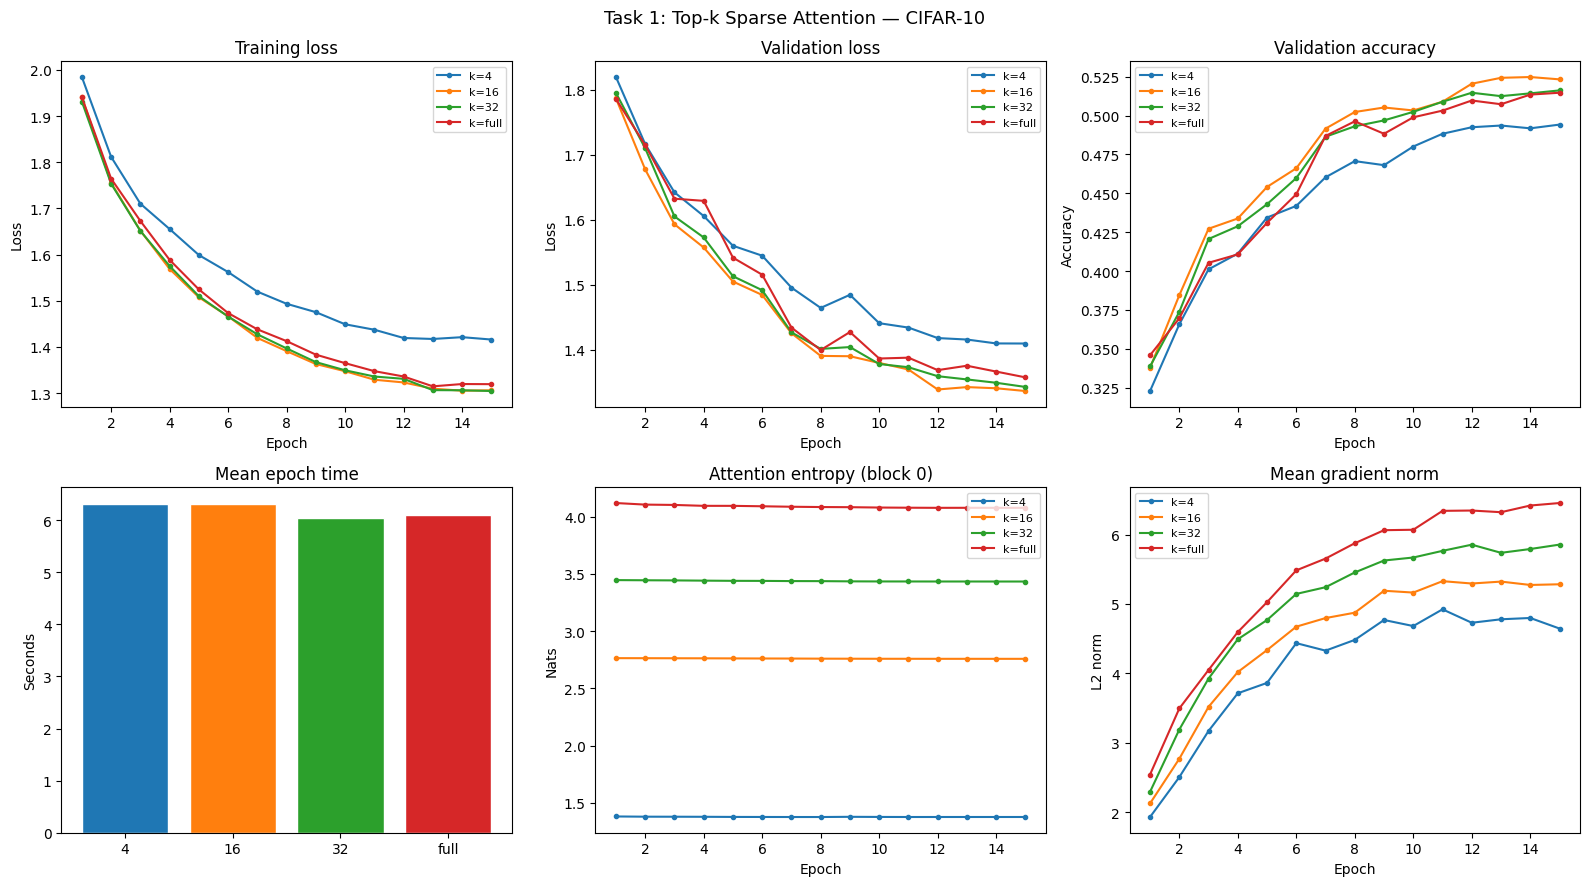

In [18]:
EPOCHS_A = len(list(topk_res.values())[0]['tr_loss'])
epochs_ax = range(1, EPOCHS_A + 1)
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
ax_trloss, ax_valloss, ax_valacc, ax_time, ax_ent, ax_gnorm = axes.flatten()

for i, (label, res) in enumerate(topk_res.items()):
    c = colors[i]
    kw = dict(color=c, marker='o', markersize=3)
    ax_trloss.plot(epochs_ax, res['tr_loss'],   label=f'k={label}', **kw)
    ax_valloss.plot(epochs_ax, res['val_loss'],  label=f'k={label}', **kw)
    ax_valacc.plot(epochs_ax, res['val_acc'],   label=f'k={label}', **kw)
    ax_ent.plot(epochs_ax,    res['entropy'],   label=f'k={label}', **kw)
    ax_gnorm.plot(epochs_ax,  res['gnorm'],     label=f'k={label}', **kw)

labels_plot = list(topk_res.keys())
times = [np.mean(topk_res[l]['epoch_time'][-3:]) for l in labels_plot]
ax_time.bar(labels_plot, times, color=[colors[i] for i in range(len(labels_plot))], edgecolor='white')

for ax, title, ylabel in [
    (ax_trloss, 'Training loss',               'Loss'),
    (ax_valloss, 'Validation loss',             'Loss'),
    (ax_valacc,  'Validation accuracy',         'Accuracy'),
    (ax_time,    'Mean epoch time',             'Seconds'),
    (ax_ent,     'Attention entropy (block 0)', 'Nats'),
    (ax_gnorm,   'Mean gradient norm',          'L2 norm'),
]:
    ax.set_title(title); ax.set_ylabel(ylabel)
    if ax != ax_time:
        ax.set_xlabel('Epoch'); ax.legend(fontsize=8)

plt.suptitle('Task 1: Top-k Sparse Attention — CIFAR-10', fontsize=13)
plt.tight_layout()
plt.show()


**[1.3 cont.] Visualisation A1b — Per-class accuracy heatmap (final epoch).**

/tmp/ipykernel_55/4154662898.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
/tmp/ipykernel_55/4154662898.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
/tmp/ipykernel_55/4154662898.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
/tmp/ipykernel_55/4154662898.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)


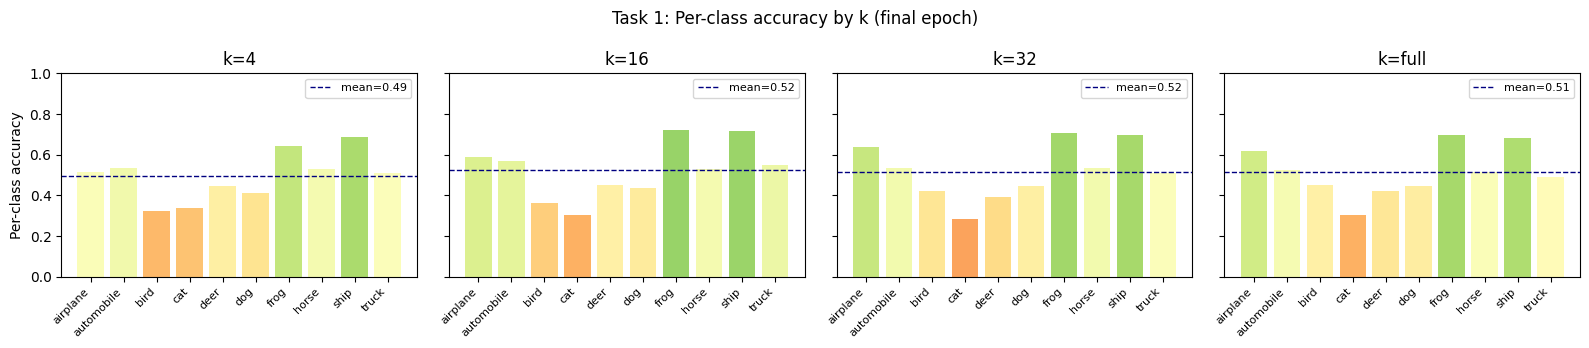

In [19]:
fig, axes = plt.subplots(1, len(topk_res), figsize=(4 * len(topk_res), 3.5), sharey=True)
if len(topk_res) == 1: axes = [axes]

for ax, (label, res) in zip(axes, topk_res.items()):
    per_cls = res['per_cls'][-1]
    ax.bar(CLASSES, per_cls, color=plt.cm.RdYlGn(per_cls))
    ax.set_title(f'k={label}')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
    ax.axhline(per_cls.mean(), linestyle='--', color='navy', linewidth=1,
               label=f'mean={per_cls.mean():.2f}')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Per-class accuracy')
plt.suptitle('Task 1: Per-class accuracy by k (final epoch)', fontsize=12)
plt.tight_layout()
plt.show()


**[1.4] Analysis — Task 1**

*Write your analysis here. Address:*
- *How does validation accuracy vary with k? Is the relationship monotonic?*
- *What does attention entropy tell you about sparsity?*
- *Comment on gradient norm trends across k.*
- *Which k would you choose in practice and why?*


==> Validation accuracy is not monotonic. its highest with 52.3% at k=16. this is better than both k=4 k=32 and k=full which had 49.4%, 51.6% and 51.5% accuracies respectively.

==> as k goes from k=full to k=4, attention entropy decreases from around 4.11 to 1.37. thus the model is concentrating more onto fewer tokens creating a less uniform distribution

==>  as k increases mean gradient norms consistently increase with it being lowest at around 4.5 with k=4, and highest at 6.4 with k=full. this shows that restricting attention to fewer patches limits the amount of gradients flowing back through the network.

==> I would choose k=16 as it achieves the highest validation accuracy and lower loss than the k=full, showing that mid level sparsity works just as well without any compromises in training time.

---
### Task 2 — Temperature-Scaled Attention

**[2.1] Fixed-temperature implementation.**

Replace the standard $1/\sqrt{d_k}$ denominator with $1/(\tau \sqrt{d_k})$.  
Confirm that `tau=1.0` recovers the baseline exactly.


In [30]:
def temperature_attention(Q, K, V, tau=1.0):
    """
    Scaled dot-product attention with temperature parameter tau.
    tau < 1 sharpens the distribution; tau > 1 smooths it.
    """
    # TODO: implement temperature-scaled attention
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (tau * math.sqrt(d_k))
    attn = F.softmax(scores, dim=-1)
    out = torch.matmul(attn, V)
    
    return out, attn


**[2.2] Learnable-temperature module.**

Implement `LearnedTemperatureAttention` as an `nn.Module`.  
Store `log_tau` as a single `nn.Parameter` (init from `init_tau`); compute `tau = exp(log_tau)` in forward.  
The module must be passable as the `attention_fn` argument (signature: `forward(Q, K, V)`).


In [32]:
class LearnedTemperatureAttention(nn.Module):
    """
    Temperature attention with tau as a single learned scalar.
    Parameterise as exp(log_tau) to ensure tau > 0 always.
    """
    def __init__(self, init_tau=1.0):
        super().__init__()
        # TODO: store log_tau as an nn.Parameter
        self.log_tau = nn.Parameter(torch.tensor([math.log(init_tau)]))

    def forward(self, Q, K, V):
        # TODO: compute tau, then temperature attention
        tau = torch.exp(self.log_tau)
        return temperature_attention(Q, K, V, tau=tau)


**[2.3] Experiment A2 — Temperature sweep.**

Run for τ ∈ {0.5, 1.0, 2.0, 4.0, 'learned'}. Training config is the same as Task 1 (EPOCHS_T = 15, LR_A).


In [33]:
# Training configuration — do not change
EPOCHS_T = 15

def run_temperature_experiment(tau_values, epochs=EPOCHS_T):
    results = {}
    for tau in tau_values:
        torch.manual_seed(42)
        label   = 'learned' if tau == 'learned' else f'tau={tau}'
        if tau == 'learned':
            lta     = LearnedTemperatureAttention(init_tau=1.0)
            attn_fn = lta
        else:
            attn_fn = lambda Q, K, V, t=tau: temperature_attention(Q, K, V, tau=t)
        model  = ViTClassifierA(attention_fn=attn_fn).to(DEVICE)
        opt    = torch.optim.Adam(model.parameters(), lr=LR_A)
        sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        r = collections.defaultdict(list)
        for ep in range(1, epochs + 1):
            tr_loss, tr_acc, gnorm = train_epoch_a(model, loader_train_a, opt, CRIT_A)
            _, val_acc, per_cls    = evaluate_a(model, loader_val_a, CRIT_A)
            ent = measure_entropy(model, loader_val_a, attn_fn)
            sched.step()
            r['tr_loss'].append(tr_loss);  r['val_acc'].append(val_acc)
            r['gnorm'].append(gnorm);      r['entropy'].append(ent)
            r['per_cls'].append(per_cls)
            if tau == 'learned':
                r['tau_val'].append(lta.log_tau.exp().item())
            print(f"  {label} ep {ep:02d}/{epochs} "
                  f"tr_loss={tr_loss:.4f} val_acc={val_acc:.3f} "
                  f"entropy={ent:.3f}")
        results[label] = dict(r)
    return results

tau_res = run_temperature_experiment([0.5, 1.0, 2.0, 4.0, 'learned'])


  tau=0.5 ep 01/15 tr_loss=1.9301 val_acc=0.348 entropy=4.019
  tau=0.5 ep 02/15 tr_loss=1.7481 val_acc=0.384 entropy=3.988
  tau=0.5 ep 03/15 tr_loss=1.6387 val_acc=0.423 entropy=3.974
  tau=0.5 ep 04/15 tr_loss=1.5582 val_acc=0.427 entropy=3.964
  tau=0.5 ep 05/15 tr_loss=1.4920 val_acc=0.445 entropy=3.956
  tau=0.5 ep 06/15 tr_loss=1.4495 val_acc=0.468 entropy=3.951
  tau=0.5 ep 07/15 tr_loss=1.4120 val_acc=0.497 entropy=3.932
  tau=0.5 ep 08/15 tr_loss=1.3862 val_acc=0.509 entropy=3.927
  tau=0.5 ep 09/15 tr_loss=1.3564 val_acc=0.499 entropy=3.919
  tau=0.5 ep 10/15 tr_loss=1.3375 val_acc=0.511 entropy=3.918
  tau=0.5 ep 11/15 tr_loss=1.3202 val_acc=0.516 entropy=3.910
  tau=0.5 ep 12/15 tr_loss=1.3102 val_acc=0.520 entropy=3.908
  tau=0.5 ep 13/15 tr_loss=1.2886 val_acc=0.517 entropy=3.908
  tau=0.5 ep 14/15 tr_loss=1.2950 val_acc=0.521 entropy=3.908
  tau=0.5 ep 15/15 tr_loss=1.2893 val_acc=0.523 entropy=3.908
  tau=1.0 ep 01/15 tr_loss=1.9408 val_acc=0.346 entropy=4.119
  tau=1.

**[2.3 cont.] Visualisation A2 — 6-panel figure.**

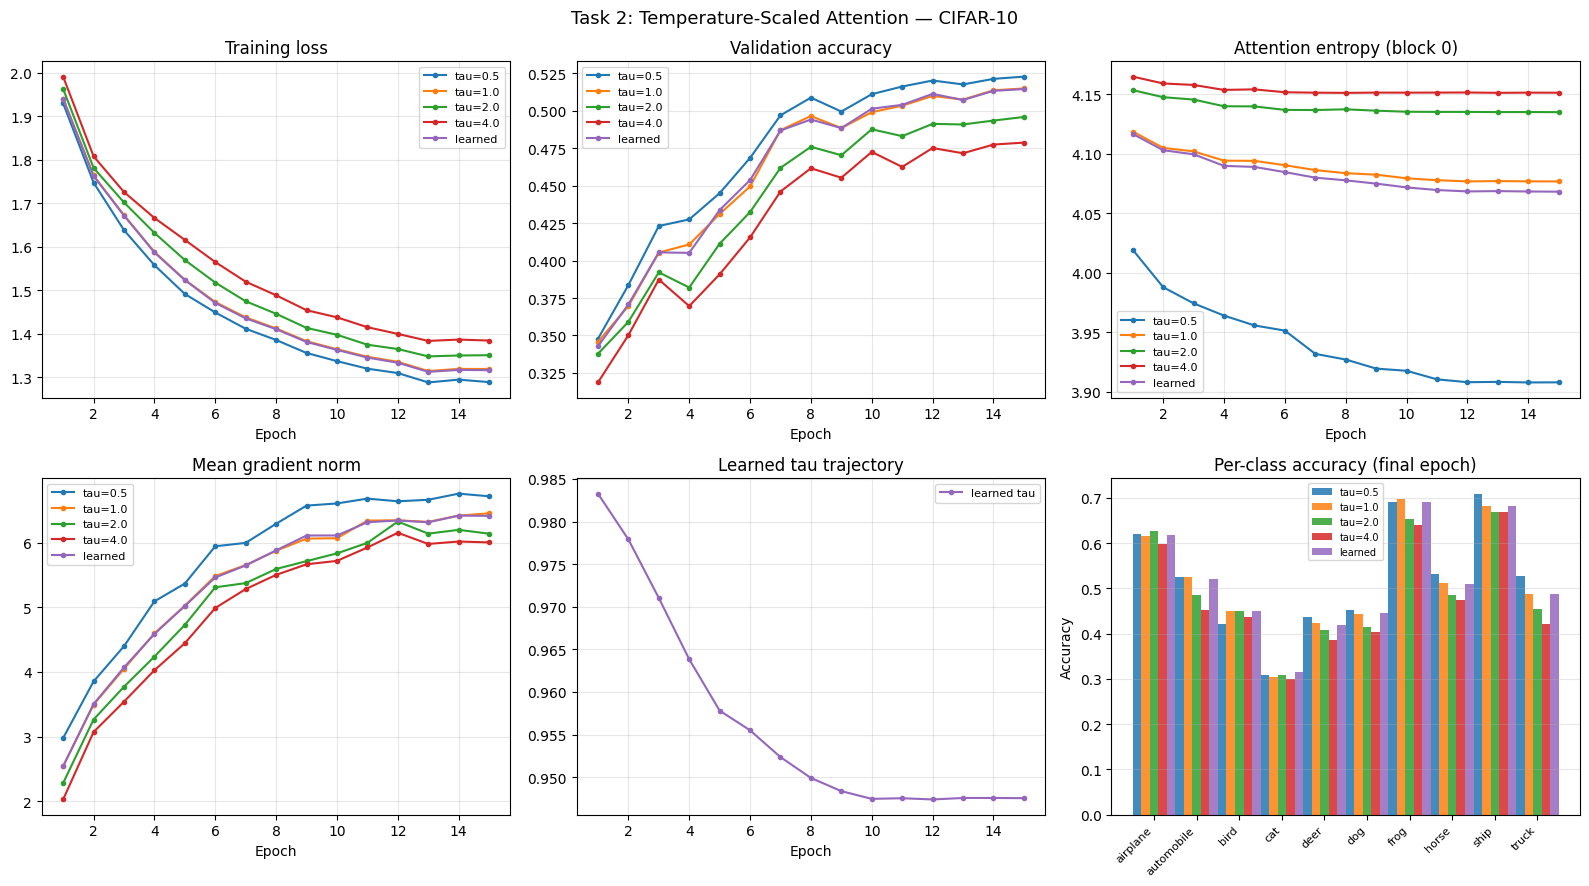

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
ax_loss, ax_acc, ax_ent, ax_gnorm, ax_tau, ax_cls = axes.flatten()
epochs_t = range(1, EPOCHS_T + 1)

for i, (label, res) in enumerate(tau_res.items()):
    c = colors[i]
    kw = dict(color=c, marker='o', markersize=3, label=label)
    ax_loss.plot(epochs_t, res['tr_loss'],  **kw)
    ax_acc.plot(epochs_t,  res['val_acc'],  **kw)
    ax_ent.plot(epochs_t,  res['entropy'],  **kw)
    ax_gnorm.plot(epochs_t, res['gnorm'],   **kw)
    if 'tau_val' in res:
        ax_tau.plot(epochs_t, res['tau_val'], color=c, marker='o',
                    markersize=3, label='learned tau')

x = np.arange(10)
width = 0.2
for i, (label, res) in enumerate(tau_res.items()):
    ax_cls.bar(x + i * width, res['per_cls'][-1],
               width=width, label=label, alpha=0.85)
ax_cls.set_xticks(x + width * 2)
ax_cls.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
ax_cls.set_ylabel('Accuracy'); ax_cls.set_title('Per-class accuracy (final epoch)')
ax_cls.legend(fontsize=7); ax_cls.grid(True, axis='y', alpha=0.3)

for ax, title in [(ax_loss, 'Training loss'),
                  (ax_acc,  'Validation accuracy'),
                  (ax_ent,  'Attention entropy (block 0)'),
                  (ax_gnorm,'Mean gradient norm'),
                  (ax_tau,  'Learned tau trajectory')]:
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Task 2: Temperature-Scaled Attention — CIFAR-10', fontsize=13)
plt.tight_layout()
plt.show()


**[2.4] Analysis — Task 2**

*Write your analysis here. Address:*
- *How do sharp (τ < 1) and flat (τ > 1) attention affect accuracy?*
- *What value does the learned τ converge to? Does it align with the fixed-τ sweep?*
- *How does temperature interact with attention entropy? Provide specific numbers.*


==> Sharp attention =tau < 1 improves validation accuracy. The tau=0.5 model achieved the highest final accuracy at 52.3%. while flat attention =tau > 1 decreases accuracy, with the tau=4.0 model giving the worst at around 47%.

==> The learned tau trajectory decreases from around 9.8 and converges to 0.94. This aligns perfectly with the fixed tau sweep results, as the model's optimization moved toward a sharper distribution tau < 1 to minimize loss.

==> Temperature has a direct, positive correlation with attention entropy. Lower temperatures force a sharper distribution due to lower entropy, while higher temperatures force a flatter distribution due to higher entropy. this is evident as we see at epoch 15, tau=0.5 produced the lowest entropy= 3.908, the baseline tau=1.0 produced entropy =4.077, and tau=4.0 produced the highest entropy =4.151.

---
### Visualisation A3 — Attention Maps on Sample CIFAR-10 Images

**[3.1]** Using the best-performing model from Task 2, extract and visualise CLS-token attention maps.  
The extraction function `get_cls_attn_map` is provided. Apply it to at least 4 validation images from different classes.


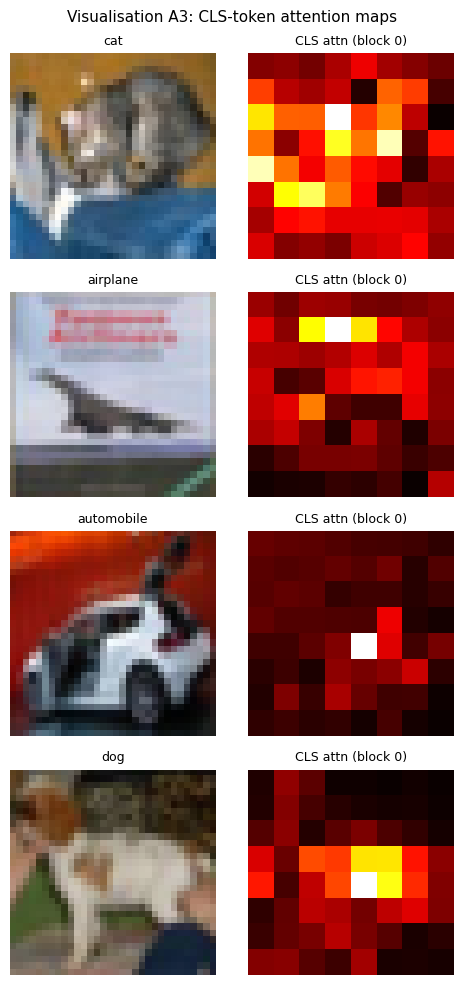

In [36]:
CIFAR_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


@torch.no_grad()
def get_cls_attn_map(model, img_tensor, attn_fn):
    """
    Returns the CLS -> patch attention weights from block 0, averaged over heads.
    Args:
        img_tensor: (1, 3, H, W)
    Returns:
        (H_p, W_p) numpy array
    """
    model.eval()
    B = 1
    tokens = model.embedding(img_tensor.to(DEVICE))
    cls = model.cls_token.expand(B, -1, -1)
    tokens = torch.cat([cls, tokens], dim=1) + model.pos_emb
    x_ln = model.blocks[0].ln1(tokens)
    d_k = model.blocks[0].attn.d_k
    n_h = model.blocks[0].attn.n_heads
    N = x_ln.size(1)
    def split(t):
        return t.view(B, N, n_h, d_k).transpose(1, 2)
    Q = split(model.blocks[0].attn.Wq(x_ln))
    K = split(model.blocks[0].attn.Wk(x_ln))
    V = split(model.blocks[0].attn.Wv(x_ln))
    _, aw = attn_fn(Q, K, V)  # (1, H, N, N)
    cls_attn = aw[0, :, 0, 1:].mean(0)  # (N_patches,)
    h_p = w_p = int(cls_attn.size(0) ** 0.5)
    return cls_attn.cpu().numpy().reshape(h_p, w_p)


# Pick 4 sample images from validation set (one per class of interest)
sample_classes = [0, 1, 3, 5]  # airplane, automobile, cat, dog
sample_imgs, sample_lbls = [], []
class_seen = set()
for img, lbl in cifar_val:
    if lbl in sample_classes and lbl not in class_seen:
        sample_imgs.append(img)
        sample_lbls.append(lbl)
        class_seen.add(lbl)
    if len(class_seen) == len(sample_classes):
        break

# TODO: select your best model from Task 2 and assign to `best_model` and `best_attn_fn`
# e.g., best_model = ...   best_attn_fn = ...

best_tau = 0.5
best_attn_fn = lambda Q, K, V: temperature_attention(Q, K, V, tau=best_tau)
best_model = ViTClassifierA(attention_fn=best_attn_fn).to(DEVICE)
opt_best = torch.optim.Adam(best_model.parameters(), lr=LR_A)
sched_best = torch.optim.lr_scheduler.CosineAnnealingLR(opt_best, T_max=EPOCHS_T)
for _ in range(EPOCHS_T):
    train_epoch_a(best_model, loader_train_a, opt_best, CRIT_A)
    sched_best.step()
    
# Visualise — original image + attention heatmap side by side
fig, axes = plt.subplots(len(sample_imgs), 2,
                         figsize=(5, 2.5 * len(sample_imgs)))

MEAN = torch.tensor([0.4914, 0.4822, 0.4465])
STD  = torch.tensor([0.2470, 0.2435, 0.2616])

for row, (img_t, lbl) in enumerate(zip(sample_imgs, sample_lbls)):
    img_vis = img_t * STD[:, None, None] + MEAN[:, None, None]
    img_vis = img_vis.permute(1, 2, 0).clamp(0, 1).numpy()

    attn_map = get_cls_attn_map(best_model,
                                img_t.unsqueeze(0),
                                best_attn_fn)

    axes[row, 0].imshow(img_vis); axes[row, 0].axis('off')
    axes[row, 0].set_title(CIFAR_CLASSES[lbl], fontsize=9)
    axes[row, 1].imshow(attn_map, cmap='hot', interpolation='nearest')
    axes[row, 1].axis('off')
    axes[row, 1].set_title('CLS attn (block 0)', fontsize=9)

plt.suptitle('Visualisation A3: CLS-token attention maps', fontsize=11)
plt.tight_layout()
plt.show()


**[3.1] Attention map analysis (2–3 sentences)**

*Is the attention spatially focused? What does this imply about what the model has learned?*


==> Yes, the attention is heavily spatially focused on the foreground objects. The heatmaps show the light colored highest attention weights together on the subjects like cat and dogs torso,even the airplane's text, while remaining dark over the backgrounds, thus isolating relevant features and focusing on them.

---
---
## Part B — Hybrid CNN + Vision Transformer

Full CIFAR-10 (50,000 training images). Additional augmentation: ColorJitter.  
**Training config:** 25 epochs, Adam lr=3e-4, weight_decay=1e-4, CosineAnnealingLR, CrossEntropyLoss(label_smoothing=0.1), grad clip=1.0.


### Dataset — CIFAR-10 (Part B)

In [37]:
import torchvision
import torchvision.transforms as T

IMG_SIZE   = 32
PATCH_SIZE = 4
BATCH_SIZE = 128

transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616)),
])
transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616)),
])

train_set_b = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=transform_train)
val_set_b   = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_set_b, batch_size=BATCH_SIZE,
                                            shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = torch.utils.data.DataLoader(val_set_b,   batch_size=256,
                                            shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_set_b)}  |  Val: {len(val_set_b)}")


Train: 50000  |  Val: 10000


---
### Task 3 — Baseline: Vanilla ViT with Linear Patch Embedding

**[4.1] Implement `LinearPatchEmbedding`.**

Flatten each P×P patch and apply a linear projection to d_model.  
Input: `(B, C, H, W)`. Output: `(B, N, d_model)` where `N = (H/P)^2`.  
Do **not** add the CLS token or positional embedding here.


In [39]:
class LinearPatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, d_model):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches  = (img_size // patch_size) ** 2
        # TODO: define the linear projection layer
        patch_dim = patch_size * patch_size * in_channels
        self.proj = nn.Linear(patch_dim, d_model)

    def forward(self, x):
        # TODO: extract patches and project to d_model
        # Hint: use x.unfold to extract patches, then reshape and project
        B, C, H, W = x.shape
        P = self.patch_size
        x = x.unfold(2, P, P).unfold(3, P, P)
        x = x.contiguous().view(B, C, -1, P, P)
        x = x.permute(0, 2, 1, 3, 4).contiguous()
        x = x.view(B, self.n_patches, -1)
        return self.proj(x)


**[4.2] Implement `VanillaViT`.**

- Accept an `embedding_cls` argument (defaulting to `LinearPatchEmbedding`).
- Prepend a learnable CLS token, add learnable positional embedding.
- Pass through all Transformer blocks (full attention, no modifications from Part A).
- Apply LayerNorm and classify from the CLS output only.
- Initialise CLS token with `trunc_normal_(std=0.02)`.


In [41]:
class VanillaViT(nn.Module):
    """
    Vision Transformer with swappable patch embedding.
    Classification from the [CLS] token output.
    """
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 d_model=128, n_layers=4, n_heads=4, num_classes=10,
                 embedding_cls=None):
        super().__init__()
        if embedding_cls is None:
            embedding_cls = LinearPatchEmbedding
        # TODO: instantiate embedding, CLS token, positional embedding, blocks, head
        self.embedding = embedding_cls(img_size, patch_size, in_channels, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_emb = nn.Parameter(torch.randn(1, self.embedding.n_patches + 1, d_model) * 0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_model * 2) 
            for _ in range(n_layers)
        ])
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # TODO: implement forward pass
        B = x.shape[0]
        tokens = self.embedding(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls_tokens, tokens], dim=1)
        tokens = tokens + self.pos_emb
        for blk in self.blocks:
            tokens = blk(tokens)
        cls_out = tokens[:, 0]
        return self.head(self.ln(cls_out))

    def n_params(self):
        return sum(p.numel() for p in self.parameters())


**Shape sanity check**

In [42]:
D_MODEL = 128
dummy   = torch.randn(4, 3, IMG_SIZE, IMG_SIZE)

lin_emb = LinearPatchEmbedding(IMG_SIZE, PATCH_SIZE, 3, D_MODEL)
# CNNPatchEmbedding will be defined in Task 4; skip for now
assert lin_emb(dummy).shape == (4, (IMG_SIZE // PATCH_SIZE)**2, D_MODEL), "LinearPatchEmbedding shape mismatch"
print('Linear embedding shape check passed:', lin_emb(dummy).shape)


Linear embedding shape check passed: torch.Size([4, 64, 128])


---
### Task 4 — Hybrid CNN Patch Embedding Stem

**[5.1] Implement `CNNPatchEmbedding`.**

Two-layer convolutional stem:
1. `Conv2d(C_in, d//2, kernel=3, stride=1, padding=1)` → ReLU (full-resolution local features)
2. `Conv2d(d//2, d, kernel=P, stride=P)` → ReLU (downsamples to patch grid, projects to d_model)

Reshape output from `(B, d, H/P, W/P)` to `(B, N, d_model)`.  
Output shape must be **identical** to `LinearPatchEmbedding` for the same input.


In [44]:
class CNNPatchEmbedding(nn.Module):
    """
    Two-layer convolutional stem.
    Layer 1: local feature extraction at full resolution.
    Layer 2: simultaneous patch downsampling and d_model projection.
    """
    def __init__(self, img_size, patch_size, in_channels, d_model):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches  = (img_size // patch_size) ** 2
        # TODO: define the two-layer conv stem
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, d_model // 2, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(d_model // 2, d_model, kernel_size=patch_size, stride=patch_size),
            nn.ReLU()
        )

    def forward(self, x):
        # TODO: apply stem, reshape to (B, N, d_model)
        x = self.stem(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        
        return x


**Shape assertion — both embeddings must have identical output shape.**

In [45]:
dummy = torch.randn(4, 3, IMG_SIZE, IMG_SIZE)
lin_emb = LinearPatchEmbedding(IMG_SIZE, PATCH_SIZE, 3, D_MODEL)
cnn_emb = CNNPatchEmbedding(IMG_SIZE, PATCH_SIZE, 3, D_MODEL)

assert lin_emb(dummy).shape == cnn_emb(dummy).shape, "Shape mismatch between embeddings"
print('Embedding output shape:', cnn_emb(dummy).shape)  # expected: (4, 64, 128)


Embedding output shape: torch.Size([4, 64, 128])


### Training & Evaluation Helpers (Part B)
Provided. Do not modify.

In [47]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0., 0, 0
    class_correct = torch.zeros(10)
    class_total   = torch.zeros(10)
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * imgs.size(0)
        preds   = logits.argmax(1)
        correct += (preds == labels).sum().item()
        n       += imgs.size(0)
        for c in range(10):
            mask = labels == c
            class_correct[c] += (preds[mask] == c).sum().item()
            class_total[c]   += mask.sum().item()
    per_class = (class_correct / class_total.clamp(min=1)).numpy()
    return total_loss / n, correct / n, per_class


**[5.2] Training — 25 epochs, full CIFAR-10.**

Run both models. Training config is fixed below. Do not change hyperparameters.


In [48]:
# Training configuration — do not change
EPOCHS = 25
LR     = 3e-4

results = {}

for name, emb_cls in [('Vanilla ViT',   LinearPatchEmbedding),
                       ('Hybrid CNN+ViT', CNNPatchEmbedding)]:
    torch.manual_seed(42)
    model = VanillaViT(
        img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=3,
        d_model=D_MODEL, n_layers=4, n_heads=4, num_classes=10,
        embedding_cls=emb_cls
    ).to(DEVICE)
    print(f"{name}: {model.n_params():,} parameters")

    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    per_class_history = []
    epoch_times = []

    for epoch in range(1, EPOCHS + 1):
        t0 = time.perf_counter()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, per_cls = evaluate(model, val_loader, criterion)
        scheduler.step()
        elapsed = time.perf_counter() - t0

        train_losses.append(tr_loss); val_losses.append(val_loss)
        train_accs.append(tr_acc);   val_accs.append(val_acc)
        per_class_history.append(per_cls)
        epoch_times.append(elapsed)

        print(f"{name} | ep {epoch:02d}/{EPOCHS} "
              f"tr_loss={tr_loss:.4f} val_loss={val_loss:.4f} "
              f"tr_acc={tr_acc:.3f} val_acc={val_acc:.3f} ({elapsed:.1f}s)")

    results[name] = {
        'train_loss': train_losses, 'val_loss':   val_losses,
        'train_acc':  train_accs,   'val_acc':    val_accs,
        'per_class':  per_class_history,
        'n_params':   model.n_params(),
    }


Vanilla ViT: 544,138 parameters
Vanilla ViT | ep 01/25 tr_loss=1.8934 val_loss=1.7759 tr_acc=0.339 val_acc=0.419 (20.6s)
Vanilla ViT | ep 02/25 tr_loss=1.6400 val_loss=1.5587 tr_acc=0.467 val_acc=0.516 (20.7s)
Vanilla ViT | ep 03/25 tr_loss=1.5269 val_loss=1.4652 tr_acc=0.524 val_acc=0.551 (20.6s)
Vanilla ViT | ep 04/25 tr_loss=1.4555 val_loss=1.4155 tr_acc=0.558 val_acc=0.576 (20.4s)
Vanilla ViT | ep 05/25 tr_loss=1.4025 val_loss=1.3559 tr_acc=0.584 val_acc=0.604 (20.5s)
Vanilla ViT | ep 06/25 tr_loss=1.3594 val_loss=1.3312 tr_acc=0.606 val_acc=0.616 (20.5s)
Vanilla ViT | ep 07/25 tr_loss=1.3237 val_loss=1.2788 tr_acc=0.624 val_acc=0.646 (20.2s)
Vanilla ViT | ep 08/25 tr_loss=1.2884 val_loss=1.2480 tr_acc=0.641 val_acc=0.658 (20.7s)
Vanilla ViT | ep 09/25 tr_loss=1.2584 val_loss=1.2384 tr_acc=0.651 val_acc=0.659 (20.5s)
Vanilla ViT | ep 10/25 tr_loss=1.2297 val_loss=1.2134 tr_acc=0.668 val_acc=0.682 (20.7s)
Vanilla ViT | ep 11/25 tr_loss=1.2022 val_loss=1.2254 tr_acc=0.679 val_acc=0.6

**[5.3] Visualisation B — Loss curves, accuracy, generalisation gap.**

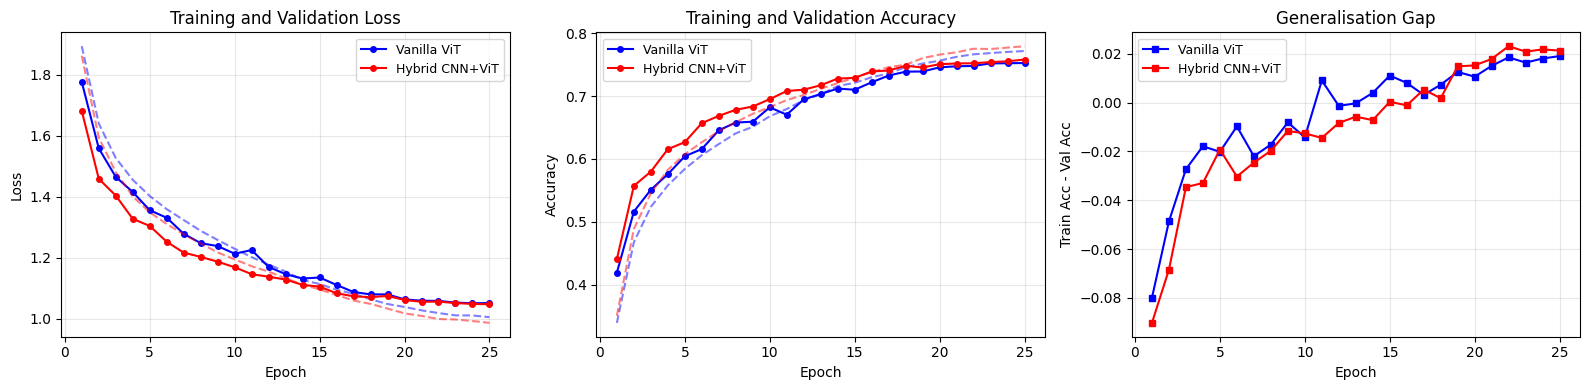

In [50]:
#TODO: plot training curves for both models (loss, accuracy, generalisation gap)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_ax = range(1, EPOCHS + 1)
colors = {'Vanilla ViT': 'blue', 'Hybrid CNN+ViT': 'red'}
for name, res in results.items():
    c = colors[name]
    axes[0].plot(epochs_ax, res['train_loss'], color=c, linestyle='--', alpha=0.5)
    axes[0].plot(epochs_ax, res['val_loss'], color=c, marker='o', markersize=4, label=name)
    axes[1].plot(epochs_ax, res['train_acc'], color=c, linestyle='--', alpha=0.5)
    axes[1].plot(epochs_ax, res['val_acc'], color=c, marker='o', markersize=4, label=name)
    gap = np.array(res['train_acc']) - np.array(res['val_acc'])
    axes[2].plot(epochs_ax, gap, color=c, marker='s', markersize=4, label=name)
axes[0].set_title('Training and Validation Loss'); axes[0].set_ylabel('Loss')
axes[1].set_title('Training and Validation Accuracy'); axes[1].set_ylabel('Accuracy')
axes[2].set_title('Generalisation Gap'); axes[2].set_ylabel('Train Acc - Val Acc')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**[5.3 cont.] Per-class accuracy heatmaps over training.**

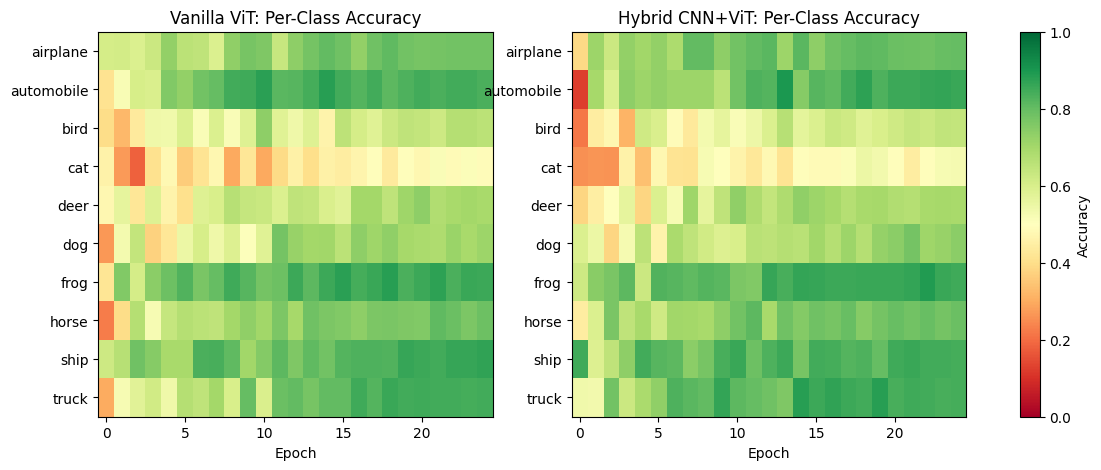

In [51]:
#TODO: plot per-class accuracy over epochs as a heatmap for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, results.keys()):
    data = np.array(results[name]['per_class']).T 
    im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_title(f'{name}: Per-Class Accuracy')
    ax.set_yticks(range(10))
    ax.set_yticklabels(CLASSES)
    ax.set_xlabel('Epoch')
    
fig.colorbar(im, ax=axes.ravel().tolist(), label='Accuracy')
plt.show()

**[5.3 cont.] Final per-class comparison bar chart + summary table.**

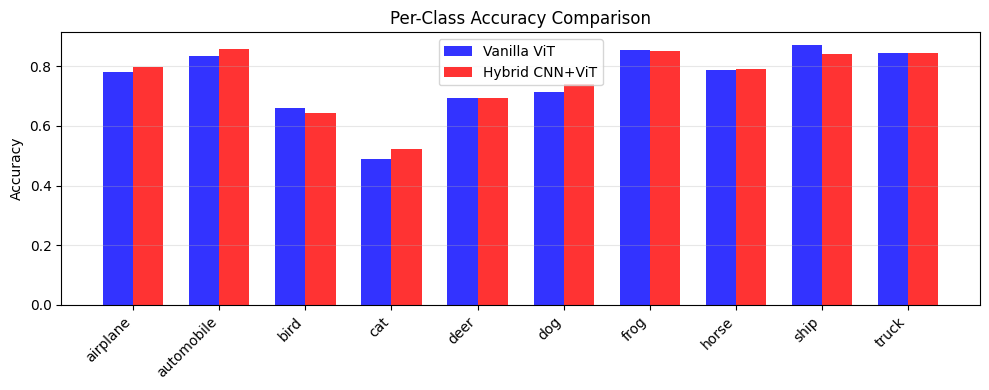


Model              | Params   | Val Acc  | Gen Gap 
-------------------------------------------------------
Vanilla ViT        | 544,138  | 0.753   | 0.019
Hybrid CNN+ViT     | 670,858  | 0.758   | 0.021


In [52]:
#TODO: plot bar chart of final per-class accuracy for both models side by side, and print a table of results
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(10)
width = 0.35
for i, (name, res) in enumerate(results.items()):
    ax.bar(x + i * width, res['per_class'][-1], width, label=name, color=colors[name], alpha=0.8)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy Comparison')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("\n" + "="*55)
print(f"{'Model':<18} | {'Params':<8} | {'Val Acc':<8} | {'Gen Gap':<8}")
print("-" * 55)
for name, res in results.items():
    gap = res['train_acc'][-1] - res['val_acc'][-1]
    print(f"{name:<18} | {res['n_params']:<8,} | {res['val_acc'][-1]:.3f}   | {gap:.3f}")
print("="*55)

**[5.3] Analysis — Part B**

*Write your analysis here. Address:*
- *Does the CNN stem improve overall validation accuracy? By how much?*
- *Which classes benefit most and least? Hypothesise why.*
- *Comment on the generalisation gap. Which model generalises better?*
- *Given the parameter counts, is the improvement cost-effective?*


==> Yes, CNN stem improves overall validation accuracy slightly, by 0.5% from 0.753 in the Vanilla ViT to 0.758 in the Hybrid CNN+ViT.

==> According to the bar chart, the cat, dog, and automobile classes show the most improvements with the Hybrid model. These classes likely benefit from the CNN stem's ability to capture local textures before patch tokenization. Conversely, the bird and ship classes show slight decreases in accuracy. This may be because these classes rely more on global shape so CNN provides no advantage.

==> Both models generalize extremely well.the Vanilla ViT generalises slightly better, showing a generalisation gap of 0.019 compared to the 0.021 gap of hybrid model.

==> The improvement isnt cost-effective as the Hybrid model introduces roughly 126,000 additional parameters which is a 23% increase in model size and gives just a 0.5% gain in validation accuracy and a slightly worse generalisation gap.

---
## Patch Size Sweep (20 pts)

**[6.1] Sweep P ∈ {2, 4, 8} using the Hybrid CNN+ViT model.**

Train for 10 epochs. All other hyperparameters identical to Part B (same LR, weight_decay, label_smoothing, scheduler).  
Record: val accuracy per epoch, mean epoch time, number of tokens N, total parameters.


In [53]:
# Training configuration — do not change
EPOCHS_SWEEP = 10

patch_sweep_results = {}

for P in [2, 4, 8]:
    torch.manual_seed(42)
    # TODO: instantiate model with patch_size=P for both embeddings, and run training loop for EPOCHS_SWEEP epochs
    model = VanillaViT(
        img_size=IMG_SIZE, patch_size=P, in_channels=3,
        d_model=D_MODEL, n_layers=4, n_heads=4, num_classes=10,
        embedding_cls=CNNPatchEmbedding 
    ).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_SWEEP)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    val_accs = []
    epoch_times = []
    N_tokens = (IMG_SIZE // P) ** 2
    print(f"\nTraining P={P} (Tokens={N_tokens}, Params={model.n_params():,}) ")
    for epoch in range(1, EPOCHS_SWEEP + 1):
        t0 = time.perf_counter()
        train_one_epoch(model, train_loader, optimizer, criterion)
        _, val_acc, per_cls = evaluate(model, val_loader, criterion)
        scheduler.step()
        elapsed = time.perf_counter() - t0
        
        val_accs.append(val_acc)
        epoch_times.append(elapsed)
        print(f"  ep {epoch:02d}/{EPOCHS_SWEEP} val_acc={val_acc:.3f} ({elapsed:.1f}s)")
    patch_sweep_results[P] = {
        'val_acc': val_accs,
        'mean_time': np.mean(epoch_times),
        'n_tokens': N_tokens,
        'n_params': model.n_params(),
        'final_per_cls': per_cls
    }



Training P=2 (Tokens=256, Params=597,130) 
  ep 01/10 val_acc=0.492 (54.3s)
  ep 02/10 val_acc=0.560 (53.5s)
  ep 03/10 val_acc=0.616 (53.9s)
  ep 04/10 val_acc=0.646 (53.8s)
  ep 05/10 val_acc=0.657 (53.7s)
  ep 06/10 val_acc=0.682 (53.7s)
  ep 07/10 val_acc=0.685 (53.8s)
  ep 08/10 val_acc=0.696 (53.8s)
  ep 09/10 val_acc=0.710 (53.7s)
  ep 10/10 val_acc=0.712 (53.6s)

Training P=4 (Tokens=64, Params=670,858) 
  ep 01/10 val_acc=0.451 (20.6s)
  ep 02/10 val_acc=0.549 (20.6s)
  ep 03/10 val_acc=0.589 (20.4s)
  ep 04/10 val_acc=0.615 (20.8s)
  ep 05/10 val_acc=0.626 (20.4s)
  ep 06/10 val_acc=0.660 (20.8s)
  ep 07/10 val_acc=0.673 (20.5s)
  ep 08/10 val_acc=0.677 (20.6s)
  ep 09/10 val_acc=0.691 (20.7s)
  ep 10/10 val_acc=0.692 (20.6s)

Training P=8 (Tokens=16, Params=1,057,930) 
  ep 01/10 val_acc=0.435 (21.0s)
  ep 02/10 val_acc=0.517 (21.1s)
  ep 03/10 val_acc=0.564 (20.9s)
  ep 04/10 val_acc=0.591 (21.0s)
  ep 05/10 val_acc=0.608 (21.0s)
  ep 06/10 val_acc=0.622 (21.0s)
  ep 07/10

**[6.2] Visualisation — accuracy curves, epoch time, accuracy vs. token count.**

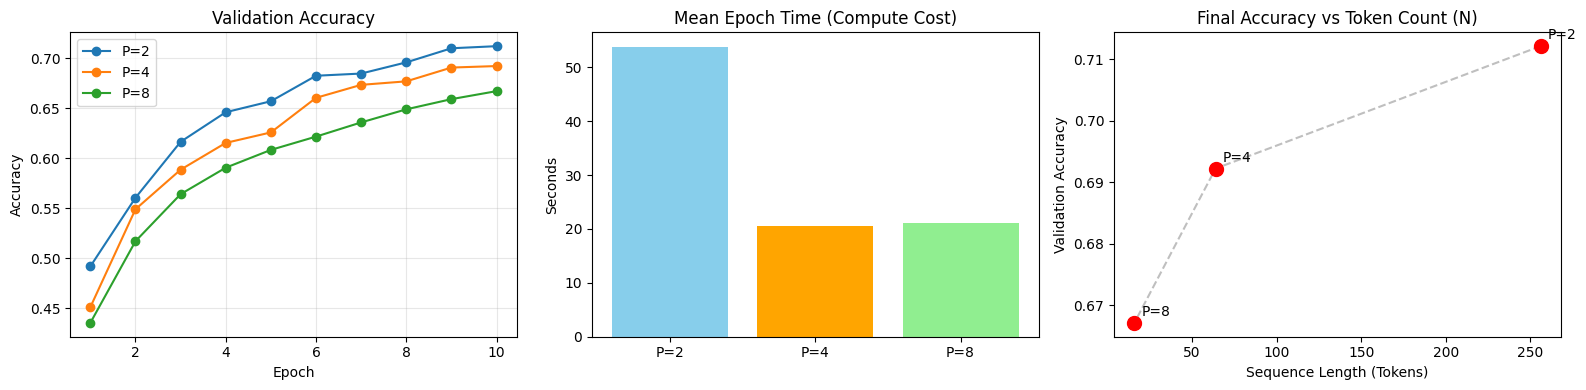


Summary:
P= 2 | Val Acc: 0.712 | Tokens: 256 | Params: 597,130 | Mean Time: 53.8s
P= 4 | Val Acc: 0.692 | Tokens:  64 | Params: 670,858 | Mean Time: 20.6s
P= 8 | Val Acc: 0.667 | Tokens:  16 | Params: 1,057,930 | Mean Time: 21.0s


In [54]:
#TODO: plot training curves for different patch sizes, and print final validation accuracies and per-class accuracies at the end of the sweep

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for P, res in patch_sweep_results.items():
    axes[0].plot(range(1, EPOCHS_SWEEP + 1), res['val_acc'], marker='o', label=f'P={P}')
axes[0].set_title('Validation Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

P_labels = [f"P={P}" for P in patch_sweep_results.keys()]
times = [res['mean_time'] for res in patch_sweep_results.values()]
axes[1].bar(P_labels, times, color=['skyblue', 'orange', 'lightgreen'])
axes[1].set_title('Mean Epoch Time (Compute Cost)'); axes[1].set_ylabel('Seconds')

tokens = [res['n_tokens'] for res in patch_sweep_results.values()]
final_accs = [res['val_acc'][-1] for res in patch_sweep_results.values()]
axes[2].scatter(tokens, final_accs, s=100, color='red', zorder=5)
for i, p in enumerate(patch_sweep_results.keys()):
    axes[2].annotate(f'P={p}', (tokens[i], final_accs[i]), xytext=(5,5), textcoords='offset points')
axes[2].plot(tokens, final_accs, linestyle='--', color='gray', alpha=0.5)
axes[2].set_title('Final Accuracy vs Token Count (N)')
axes[2].set_xlabel('Sequence Length (Tokens)'); axes[2].set_ylabel('Validation Accuracy')
plt.tight_layout()
plt.show()

print("\nSummary:")
for P, res in patch_sweep_results.items():
    print(f"P={P:2d} | Val Acc: {res['val_acc'][-1]:.3f} | Tokens: {res['n_tokens']:>3} | Params: {res['n_params']:>7,} | Mean Time: {res['mean_time']:>4.1f}s")

**[6.3] Analysis — Patch Size Sweep**

*Write your analysis here. Address:*
- *How does validation accuracy scale with P? Is the relationship monotonic?*
- *Quantify the compute cost (epoch time) for each P. At what point do diminishing returns set in?*
- *For a deployment scenario with a hard latency budget, which P would you recommend?*


==> Validation accuracy goes inversely with patch size P. The relationship is strictly monotonic across the tested values, as it drops from 0.712 with P=2, to 0.692 with P=4), down to 0.667 with P=8.

==> Mean epoch times are 53.8s for P=2, 20.6s for P=4, and 21.0s for P=8. Diminishing returns in compute speed set in after P=4. Increasing the patch size from 4 to 8 provides zero benefit in speed as time slightly increases by 0.4s while 2.5% accuracy is lost.

==> I recommend P=4. It offers the fastest compute time =20.6s per epoch while maintaining accuracy of 0.692. P=2 takes quite long to process =53.8s, and P=8 provides worse accuracy with no benefit in speed over P=4.